# XGBoost with Dynamic Triple Barrier Labels

Signal from FinBERT embeddings + topic probs + market indicators. Target = forward 1m return vs 0.3*rolling vol.

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                             precision_score, confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

DATA_DIR = '../data'
SAMPLE = False
N_PCA = 10                  # fewer components -> less noise
VOL_WIN = 21
FWD_WIN = 5
BARRIER_K = 0.5
CV_GAP = FWD_WIN + 2
N_SPLITS = 3                # larger training windows
ROLL_PCT_WIN = 21
ROLL_PCT_MIN = 5
PCT_LEVEL = 0.60

## Load data

In [2]:
news_lf = (pl.scan_parquet(f'{DATA_DIR}/preprocessed/subset_news.parquet')
           .select(['id', 'Stock_symbol', 'date_parsed'])
           .rename({'Stock_symbol': 'ticker', 'date_parsed': 'date'})
           .with_columns(pl.col('date').cast(pl.Date)))

if SAMPLE:
    keep = ['GOOG', 'MSFT', 'TSLA', 'GS', 'XOM']
    news_lf = news_lf.filter(pl.col('ticker').is_in(keep))

news = news_lf.collect()
ids = news['id'].to_list()
tickers_news = news['ticker'].unique().to_list()

fin_schema = pl.scan_parquet(f'{DATA_DIR}/predictions/finbert_embeddings.parquet').collect_schema()
emb_cols = [c for c in fin_schema.names() if c.startswith('emb_')]

fin = (pl.scan_parquet(f'{DATA_DIR}/predictions/finbert_embeddings.parquet')
       .select(['id', 'score'] + emb_cols)
       .filter(pl.col('id').is_in(ids))
       .with_columns([pl.col(c).cast(pl.Float32) for c in emb_cols])
       .collect())

topics_lf = pl.scan_parquet(f'{DATA_DIR}/predictions/full_df_topic_probabilities.parquet')
topic_cols = [c for c in topics_lf.collect_schema().names() if c.startswith('prob_')]
topics = topics_lf.filter(pl.col('id').is_in(ids)).collect()

prices = (pl.scan_parquet(f'{DATA_DIR}/Stock_price/stock_price.parquet')
          .filter(pl.col('ticker').is_in(tickers_news))
          .with_columns(pl.col('date').cast(pl.Date))
          .sort(['ticker', 'date'])
          .collect())

print('news', news.shape, 'fin', fin.shape, 'topics', topics.shape, 'prices', prices.shape)

news (139522, 3) fin (139522, 770) topics (139522, 14) prices (245996, 8)


## Dynamic triple-barrier target

Forward window 21d, barrier = 0.3 * rolling 21d vol. Entry = next day close to avoid leakage.

In [3]:
px = prices.with_columns([
    pl.col('close').pct_change().over('ticker').alias('ret'),
]).with_columns([
    pl.col('ret').rolling_std(VOL_WIN).over('ticker').alias('vol'),
    pl.col('close').shift(-1).over('ticker').alias('entry'),
    pl.col('close').shift(-1 - FWD_WIN).over('ticker').alias('exit'),
])
px = px.with_columns([
    (pl.col('exit') / pl.col('entry') - 1).alias('fwd_ret'),
]).with_columns([
    pl.when(pl.col('fwd_ret') > BARRIER_K * pl.col('vol')).then(1)
      .when(pl.col('fwd_ret') < -BARRIER_K * pl.col('vol')).then(0)
      .otherwise(None).alias('label'),
]).drop_nulls(['label', 'vol']).with_columns(pl.col('label').cast(pl.Int8))

print(px.select(['ticker', 'date', 'ret', 'vol', 'fwd_ret', 'label']).head())
print('label balance:', px['label'].value_counts().to_dict())

shape: (5, 6)
┌────────┬────────────┬───────────┬──────────┬──────────┬───────┐
│ ticker ┆ date       ┆ ret       ┆ vol      ┆ fwd_ret  ┆ label │
│ ---    ┆ ---        ┆ ---       ┆ ---      ┆ ---      ┆ ---   │
│ str    ┆ date       ┆ f64       ┆ f64      ┆ f64      ┆ i8    │
╞════════╪════════════╪═══════════╪══════════╪══════════╪═══════╡
│ CAT    ┆ 1970-02-03 ┆ 0.020548  ┆ 0.013577 ┆ 0.027211 ┆ 1     │
│ CAT    ┆ 1970-02-04 ┆ -0.013423 ┆ 0.013005 ┆ 0.020548 ┆ 1     │
│ CAT    ┆ 1970-02-05 ┆ -0.006803 ┆ 0.011521 ┆ 0.024055 ┆ 1     │
│ CAT    ┆ 1970-02-06 ┆ -0.003425 ┆ 0.011426 ┆ 0.010135 ┆ 1     │
│ CAT    ┆ 1970-02-11 ┆ 0.010033  ┆ 0.011764 ┆ 0.050336 ┆ 1     │
└────────┴────────────┴───────────┴──────────┴──────────┴───────┘
label balance: {'label': shape: (2,)
Series: 'label' [i8]
[
	0
	1
], 'count': shape: (2,)
Series: 'count' [u32]
[
	91286
	107572
]}


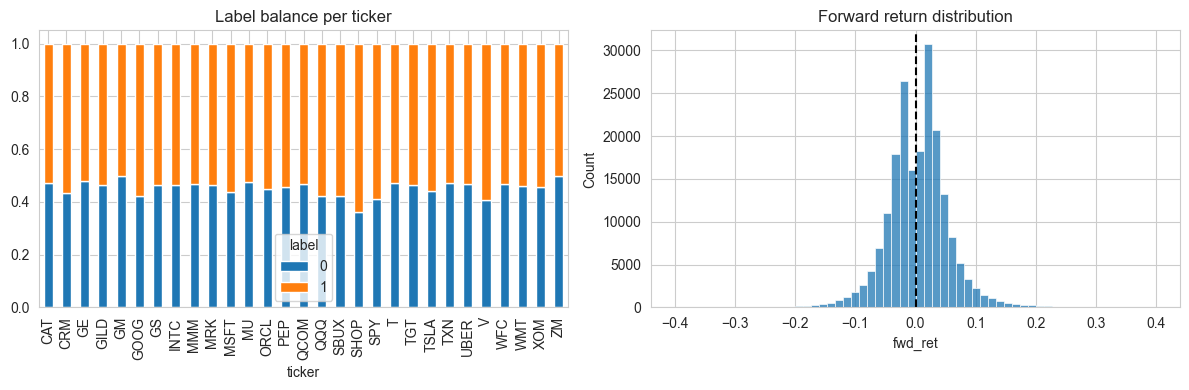

            vol                                                          \
          count    mean     std     min     25%     50%     75%     max   
ticker                                                                    
CAT     11185.0  0.0171  0.0073  0.0048  0.0123  0.0157  0.0204  0.0758   
CRM      3947.0  0.0236  0.0113  0.0050  0.0150  0.0218  0.0292  0.0803   
GE      12740.0  0.0150  0.0080  0.0025  0.0100  0.0129  0.0174  0.0839   
GILD     6436.0  0.0256  0.0148  0.0050  0.0141  0.0204  0.0337  0.0856   
GM       2693.0  0.0196  0.0089  0.0060  0.0139  0.0175  0.0226  0.0886   
GOOG     3954.0  0.0169  0.0083  0.0038  0.0111  0.0148  0.0203  0.0574   
GS       5100.0  0.0193  0.0118  0.0043  0.0123  0.0158  0.0222  0.0976   
INTC     9009.0  0.0225  0.0102  0.0052  0.0156  0.0213  0.0270  0.1043   
MMM     10315.0  0.0132  0.0058  0.0028  0.0095  0.0120  0.0154  0.0586   
MRK     11074.0  0.0144  0.0061  0.0041  0.0104  0.0132  0.0167  0.0615   
MSFT     7627.0  0.0186  

In [4]:
px_pd = px.to_pandas()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(px_pd.groupby('ticker')['label'].value_counts(normalize=True)
      .unstack().plot.bar(stacked=True, ax=ax[0]))
ax[0].set_title('Label balance per ticker')
sns.histplot(px_pd['fwd_ret'].clip(-0.4, 0.4), bins=60, ax=ax[1])
ax[1].axvline(0, color='k', ls='--')
ax[1].set_title('Forward return distribution')
plt.tight_layout(); plt.show()

print(px_pd.groupby('ticker')[['vol', 'fwd_ret']].describe().round(4))

## Market indicators (past-only, per-ticker)

In [5]:
market_cols = ['mkt_ret_5', 'mkt_ret_21', 'mkt_vol_21', 'mkt_vol_63',
               'mkt_mom', 'mkt_ma_ratio', 'mkt_hl', 'mkt_vol_z',
               'mkt_rsi_14', 'mkt_ret_1', 'mkt_ret_norm_5',
               'mkt_range_z', 'mkt_gap', 'mkt_xs_rank']

# RSI(14) helper
gain = pl.when(pl.col('ret') > 0).then(pl.col('ret')).otherwise(0.0)
loss = pl.when(pl.col('ret') < 0).then(-pl.col('ret')).otherwise(0.0)

px = px.with_columns([
    pl.col('ret').rolling_sum(5).over('ticker').alias('mkt_ret_5'),
    pl.col('ret').rolling_sum(21).over('ticker').alias('mkt_ret_21'),
    pl.col('ret').rolling_std(21).over('ticker').alias('mkt_vol_21'),
    pl.col('ret').rolling_std(63).over('ticker').alias('mkt_vol_63'),
    pl.col('close').pct_change(63).over('ticker').alias('mkt_mom'),
    (pl.col('close').rolling_mean(21).over('ticker') /
     pl.col('close').rolling_mean(63).over('ticker') - 1).alias('mkt_ma_ratio'),
    ((pl.col('high') - pl.col('low')) / pl.col('close')).alias('mkt_hl'),
    ((pl.col('volume') - pl.col('volume').rolling_mean(21).over('ticker')) /
      pl.col('volume').rolling_std(21).over('ticker')).alias('mkt_vol_z'),
    pl.col('ret').alias('mkt_ret_1'),
    gain.rolling_mean(14).over('ticker').alias('_g14'),
    loss.rolling_mean(14).over('ticker').alias('_l14'),
    ((pl.col('close') / pl.col('open')) - 1).alias('mkt_gap'),
]).with_columns([
    (100 - 100 / (1 + pl.col('_g14') / (pl.col('_l14') + 1e-8))).alias('mkt_rsi_14'),
    (pl.col('mkt_ret_5') / (pl.col('mkt_vol_21') * np.sqrt(5) + 1e-8)).alias('mkt_ret_norm_5'),
    ((pl.col('mkt_hl') - pl.col('mkt_hl').rolling_mean(21).over('ticker')) /
      (pl.col('mkt_hl').rolling_std(21).over('ticker') + 1e-8)).alias('mkt_range_z'),
])
# cross-sectional rank of 5d return across tickers, per date (0..1)
px = px.with_columns(
    pl.col('mkt_ret_5').rank().over('date').alias('_xs_rnk'),
).with_columns(
    (pl.col('_xs_rnk') / pl.col('_xs_rnk').max().over('date')).alias('mkt_xs_rank'),
).drop(['_g14', '_l14', '_xs_rnk']).drop_nulls(market_cols)

px.select(market_cols).describe()

statistic,mkt_ret_5,mkt_ret_21,mkt_vol_21,mkt_vol_63,mkt_mom,mkt_ma_ratio,mkt_hl,mkt_vol_z,mkt_rsi_14,mkt_ret_1,mkt_ret_norm_5,mkt_range_z,mkt_gap,mkt_xs_rank
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",197031.0,197031.0,197031.0,197031.0,197031.0,197031.0,197031.0,197031.0,197031.0,197031.0,197031.0,197031.0,197031.0,197031.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.002814,0.011728,0.018545,0.019013,0.05177,0.011444,0.024556,0.006131,52.526696,0.000565,0.075197,-0.0016,inf,0.538016
"""std""",0.047377,0.093765,0.011304,0.01047,0.220413,0.071508,0.018858,1.032997,16.454876,0.021643,1.000316,1.010555,NaN,0.289825
"""min""",-0.8922,-1.093346,0.002215,0.003379,-0.948566,-0.918248,0.0,-3.295769,-1.4211e-14,-0.329609,-4.618725,-2.758299,-0.279412,0.034483
"""25%""",-0.01973,-0.034669,0.011194,0.012007,-0.054054,-0.023327,0.012945,-0.69124,40.913794,-0.009238,-0.576025,-0.726269,-0.008086,0.285714
"""50%""",0.002695,0.01149,0.015394,0.015981,0.036649,0.012733,0.019405,-0.221086,52.590737,0.0,0.08561,-0.204187,0.0,0.538462
"""75%""",0.024984,0.057228,0.022424,0.022865,0.130081,0.045869,0.029946,0.479592,64.227894,0.009927,0.73987,0.538013,0.008981,0.789474
"""max""",0.539864,0.856513,0.126551,0.111202,7.223048,1.246471,0.458333,4.36046,99.99996,0.407844,4.252067,4.349153,inf,1.0


## News features: PCA(embeddings) + score + topic probs, aggregated per (ticker, date)

In [6]:
news_fin = news.join(fin, on='id', how='inner')

emb_mat = news_fin.select(emb_cols).to_numpy().astype(np.float32)

# Persistable embedding transform: StandardScaler + PCA in one pipeline, so we can
# joblib.dump it and reuse the exact same projection at inference time.
from sklearn.pipeline import Pipeline
emb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=N_PCA, random_state=0)),
])
emb_pca = emb_pipeline.fit_transform(emb_mat).astype(np.float32)
pca = emb_pipeline.named_steps['pca']
pca_cols = [f'pc_{i}' for i in range(N_PCA)]
print('explained var sum:', pca.explained_variance_ratio_.sum().round(3))

news_pca = pl.concat([
    news_fin.select(['id', 'ticker', 'date', 'score']),
    pl.from_numpy(emb_pca, schema=pca_cols),
], how='horizontal')

# Richer per-(ticker, date) aggregation: mean + std + extremes + count.
# Mean alone discards a lot of signal when many articles share a day.
agg_exprs = [pl.col(c).mean() for c in ['score'] + pca_cols]
agg_exprs += [pl.col('score').std().alias('score_std'),
              pl.col('score').max().alias('score_max'),
              pl.col('score').min().alias('score_min'),
              pl.col('score').abs().max().alias('score_abs_max'),
              (pl.col('score') > 0).cast(pl.Float32).mean().alias('score_pos_rate'),
              pl.len().cast(pl.Float32).alias('n_news')]
agg_fin = news_pca.group_by(['ticker', 'date']).agg(agg_exprs)

agg_tp = (news.join(topics, on='id', how='inner')
          .group_by(['ticker', 'date'])
          .agg([pl.col(c).mean() for c in topic_cols]))

agg_news = agg_fin.join(agg_tp, on=['ticker', 'date'], how='full', coalesce=True)

# Recency features: sum over last 3 days of daily mean score & news count per ticker.
agg_news = agg_news.sort(['ticker', 'date']).with_columns([
    pl.col('score').rolling_mean(3).over('ticker').alias('score_roll3'),
    pl.col('n_news').rolling_sum(3).over('ticker').alias('n_news_roll3'),
    pl.col('score').shift(1).over('ticker').alias('score_lag1'),
])

extra_cols = ['score_std', 'score_max', 'score_min', 'score_abs_max',
              'score_pos_rate', 'n_news', 'score_roll3', 'n_news_roll3', 'score_lag1']

print('agg_news', agg_news.shape)
agg_news.head(3)

explained var sum: 0.678
agg_news (47402, 35)


ticker,date,score,pc_0,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,score_std,score_max,score_min,score_abs_max,score_pos_rate,n_news,prob_big_tech_and_software,prob_semiconductors_and_hardware,prob_ai_and_machine_learning,prob_earnings_and_guidance,prob_macro_and_fed_policy,prob_oil_gas_and_energy,prob_biotech_and_pharma,prob_crypto_and_fintech,prob_ev_and_clean_energy,prob_manda_and_ipo,prob_dividends_and_income,prob_consumer_and_retail,prob_markets_and_sentiment,score_roll3,n_news_roll3,score_lag1
str,date,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f32,f64
"""CAT""",2009-11-04,0.0,2.622925,23.384466,1.04991,-2.49419,-2.367506,-0.214005,0.22249,1.487121,-0.702399,-3.697287,null,0.0,0.0,0.0,0.0,1.0,0.013,0.041529,0.003121,0.024689,0.011615,0.00766,0.01233,0.057267,0.001725,0.236309,0.022194,0.002976,0.565584,null,null,null
"""CAT""",2009-11-18,0.0,14.395138,12.505834,1.983192,-1.769795,-4.360117,-4.31605,-0.638633,2.555097,-5.403371,-2.853772,null,0.0,0.0,0.0,0.0,1.0,0.002916,0.000221,0.000517,0.003432,0.889029,0.001056,0.003662,0.010636,0.002262,0.028776,0.004768,0.005137,0.047588,null,null,0.0
"""CAT""",2010-02-05,0.0,7.699266,11.717731,3.354918,-2.250212,-3.492388,6.027184,3.40494,8.071648,-5.214756,-2.369054,null,0.0,0.0,0.0,0.0,1.0,0.018708,0.003084,0.000661,0.000943,0.788037,0.019718,0.00479,0.123747,0.008216,0.018276,0.001763,0.001078,0.010981,0.0,3.0,0.0


In [7]:
news_cols = ['score'] + pca_cols + topic_cols + extra_cols

df = (px.join(agg_news, on=['ticker', 'date'], how='inner')
        .drop_nulls(news_cols + market_cols + ['label'])
        .sort('date')).to_pandas()

# Per-ticker one-hot so models can learn ticker-specific baselines / drifts.
ticker_dum = pd.get_dummies(df['ticker'], prefix='tkr').astype(np.float32)
df = pd.concat([df, ticker_dum], axis=1)
tkr_cols = ticker_dum.columns.tolist()

feat_cols = news_cols + market_cols + tkr_cols

print('final modelling df', df.shape, 'feat_cols', len(feat_cols))
print('label balance:', df['label'].value_counts(normalize=True).round(3).to_dict())
print('rows per ticker:\n', df['ticker'].value_counts().head())
df[['date', 'ticker', 'label'] + feat_cols[:6]].head()

final modelling df (20957, 89) feat_cols 75
label balance: {1: 0.544, 0: 0.456}
rows per ticker:
 ticker
QQQ     1528
GE      1389
GS      1196
T       1160
GILD    1154
Name: count, dtype: int64


,date,ticker,label,score,pc_0,pc_1,pc_2,pc_3,pc_4
0,2010-04-22,QCOM,1,0.0,-16.958036,5.590019,3.082695,-4.024127,-2.067233
1,2010-04-26,CAT,0,0.0,-6.283020,-6.926955,-3.756311,-0.377923,-7.057398
2,2010-04-29,V,0,0.0,2.985505,0.210884,-6.437172,0.479658,-5.345050
3,2010-05-04,MRK,0,0.0,-9.148438,12.231810,-3.287614,-1.973894,-4.974774
4,2010-05-21,V,0,0.0,-5.706620,-5.341115,0.535112,-4.399168,5.950624


## Train with TimeSeriesSplit

In [8]:
# Class balance used for XGB scale_pos_weight and sanity checks
pos_rate = float((df['label'] == 1).mean())
spw = (1 - pos_rate) / max(pos_rate, 1e-6)
print('pos_rate:', round(pos_rate, 3), '  scale_pos_weight:', round(spw, 3))

models = {
    'xgb': XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.03,
                          subsample=0.8, colsample_bytree=0.8,
                          reg_lambda=1.0, min_child_weight=5,
                          scale_pos_weight=spw,
                          eval_metric='logloss', n_jobs=-1, random_state=0),
    'logreg': LogisticRegression(max_iter=1000, C=0.5,
                                  class_weight='balanced', n_jobs=-1),
    'rf': RandomForestClassifier(n_estimators=400, max_depth=8,
                                  min_samples_leaf=20,
                                  class_weight='balanced_subsample',
                                  n_jobs=-1, random_state=0),
}

def eval_fold(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {
        'roc_auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'thr': thr,
    }

def best_threshold(y_true, y_prob):
    # pick threshold maximizing F1 on training fold (coarse grid)
    grid = np.linspace(0.3, 0.7, 41)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in grid]
    return float(grid[int(np.argmax(f1s))])

X = df[feat_cols].values
y = df['label'].values
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=CV_GAP)
results, preds_store = [], {}

for name, mdl in models.items():
    fold_preds = []
    for fold, (tr, te) in enumerate(tscv.split(X)):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr]); Xte = scaler.transform(X[te])
        m = mdl.__class__(**mdl.get_params())
        m.fit(Xtr, y[tr])
        # threshold tuned on TRAIN predictions only (no test leakage)
        prob_tr = m.predict_proba(Xtr)[:, 1]
        thr = best_threshold(y[tr], prob_tr)
        prob = m.predict_proba(Xte)[:, 1]
        met = eval_fold(y[te], prob, thr=thr)
        met.update({'model': name, 'fold': fold, 'n_tr': len(tr), 'n_te': len(te)})
        results.append(met)
        fold_preds.append(pd.DataFrame({
            'idx': te, 'date': df['date'].values[te], 'ticker': df['ticker'].values[te],
            'y': y[te], 'proba': prob, 'fold': fold, 'thr': thr,
        }))
    preds_store[name] = pd.concat(fold_preds, ignore_index=True)

res_df = pd.DataFrame(results)
print(res_df.groupby('model')[['roc_auc', 'f1', 'recall', 'precision', 'thr']].mean().round(3))
res_df

pos_rate: 0.544   scale_pos_weight: 0.839


/opt/anaconda3/envs/ie_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/ie_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/ie_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


        roc_auc     f1  recall  precision    thr
model                                           
logreg    0.509  0.682   0.922      0.542  0.320
rf        0.503  0.619   0.727      0.544  0.487
xgb       0.503  0.598   0.669      0.543  0.477


,roc_auc,f1,recall,precision,thr,model,fold,n_tr,n_te
0,0.506176,0.602814,0.637686,0.571559,0.47,xgb,0,5233,5239
1,0.503465,0.606930,0.729541,0.519603,0.48,xgb,1,10472,5239
2,0.500185,0.584190,0.640818,0.536758,0.48,xgb,2,15711,5239
3,0.509553,0.720098,0.993911,0.564566,0.30,logreg,0,5233,5239
4,0.507499,0.658353,0.900917,0.518698,0.33,logreg,1,10472,5239
5,0.508682,0.668558,0.872048,0.542068,0.33,logreg,2,15711,5239
6,0.500302,0.597448,0.633627,0.565178,0.49,rf,0,5233,5239
7,0.508025,0.640432,0.827156,0.522485,0.48,rf,1,10472,5239
8,0.499936,0.619927,0.721537,0.543403,0.49,rf,2,15711,5239


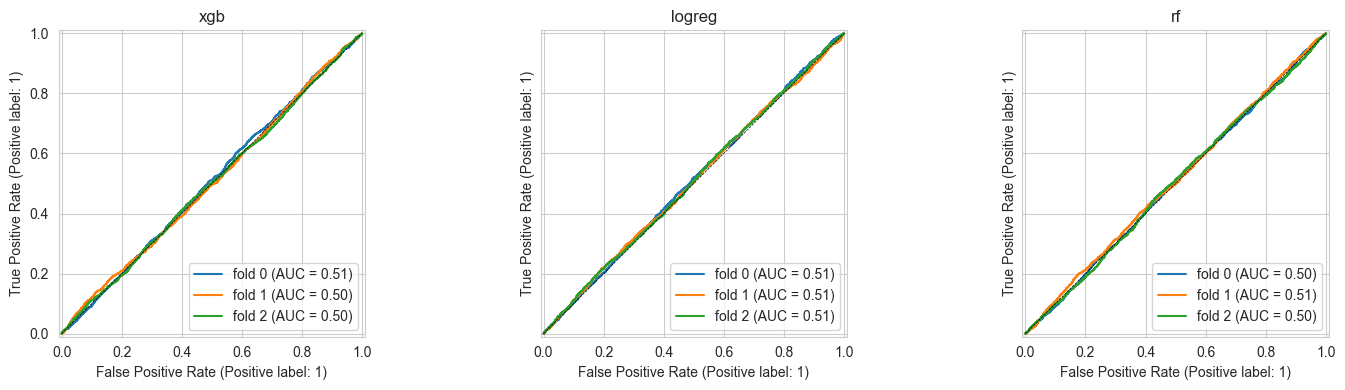

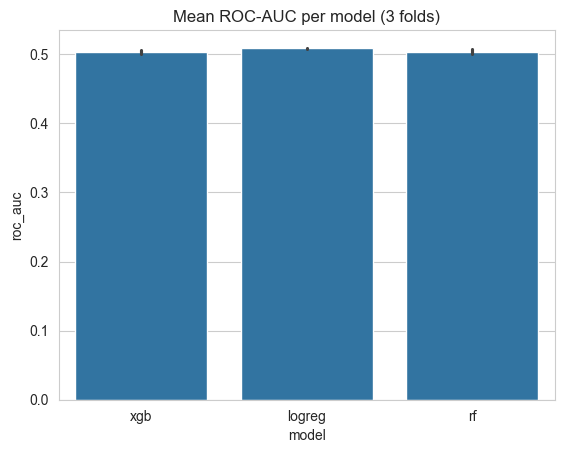

In [9]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), sharey=True)
for ax, (name, p) in zip(np.atleast_1d(axes), preds_store.items()):
    for f in sorted(p['fold'].unique()):
        sub = p[p['fold'] == f]
        RocCurveDisplay.from_predictions(sub['y'], sub['proba'], name=f'fold {f}', ax=ax)
    ax.set_title(name); ax.plot([0, 1], [0, 1], 'k--', lw=0.5)
plt.tight_layout(); plt.show()

sns.barplot(res_df, x='model', y='roc_auc')
plt.title('Mean ROC-AUC per model (3 folds)'); plt.show()

## Post-hoc: rolling 60th-percentile threshold per ticker

Signal = +1 if proba > rolling p60(proba), -1 if (1-proba) > rolling p60(1-proba), else 0.

In [10]:
def posthoc_signal(p, win=ROLL_PCT_WIN, min_p=ROLL_PCT_MIN, level=PCT_LEVEL):
    p = p.sort_values(['ticker', 'date']).copy()
    p['long_p'] = p['proba']
    p['short_p'] = 1 - p['proba']
    def roll_q(s):
        return s.rolling(win, min_periods=min_p).quantile(level)
    p['long_thr'] = p.groupby('ticker')['long_p'].transform(roll_q)
    p['short_thr'] = p.groupby('ticker')['short_p'].transform(roll_q)
    long_sig = p['long_p'] > p['long_thr']
    short_sig = p['short_p'] > p['short_thr']
    sig = np.where(long_sig & ~short_sig, 1,
            np.where(short_sig & ~long_sig, -1,
              np.where(long_sig & short_sig,
                       np.sign(p['long_p'] - p['short_p']), 0)))
    p['signal'] = sig
    return p

best = res_df.groupby('model')['roc_auc'].mean().idxmax()
print('best model:', best)
ph = posthoc_signal(preds_store[best])
ph['y_dir'] = np.where(ph['y'] == 1, 1, -1)   # long/short truth
ph_act = ph[ph['signal'] != 0].copy()
ph_act['correct'] = (ph_act['signal'] == ph_act['y_dir']).astype(int)

print('coverage:', len(ph_act) / len(ph))
print('directional accuracy:', ph_act['correct'].mean().round(3))
print(ph_act.groupby('ticker')['correct'].agg(['mean', 'count']).round(3))

best model: logreg
coverage: 0.7718394095565312
directional accuracy: 0.5
         mean  count
ticker              
CAT     0.483    408
CRM     0.525    541
GE      0.520    650
GILD    0.541    466
GM      0.750      4
GOOG    0.483    745
GS      0.518    749
INTC    0.487    809
MMM     0.452    115
MRK     0.528    585
MSFT    0.500    250
MU      0.514    455
ORCL    0.492    264
PEP     0.411    343
QCOM    0.500    402
QQQ     0.490    649
SBUX    0.457    247
SPY     0.485    460
T       0.502    751
TGT     0.579    197
TSLA    0.544    261
TXN     0.518    170
UBER    0.459     74
V       0.533    540
WFC     0.452    507
WMT     0.505    713
XOM     0.501    535
ZM      0.436    241


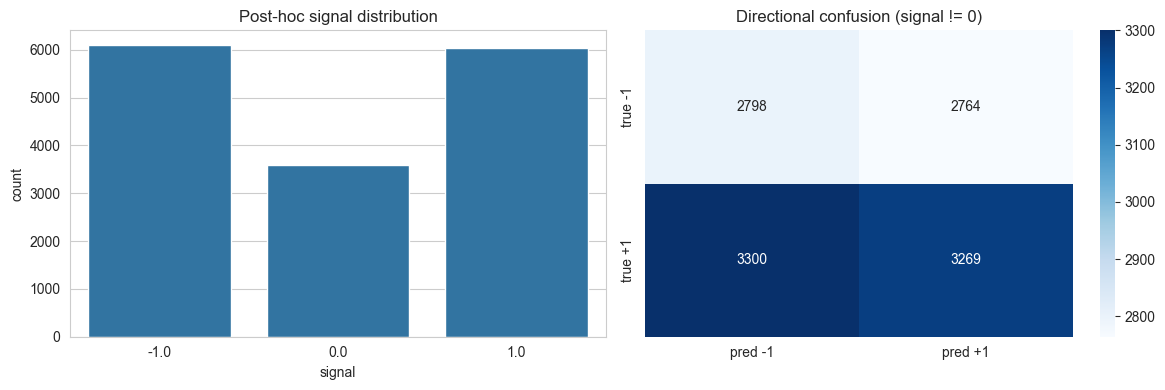

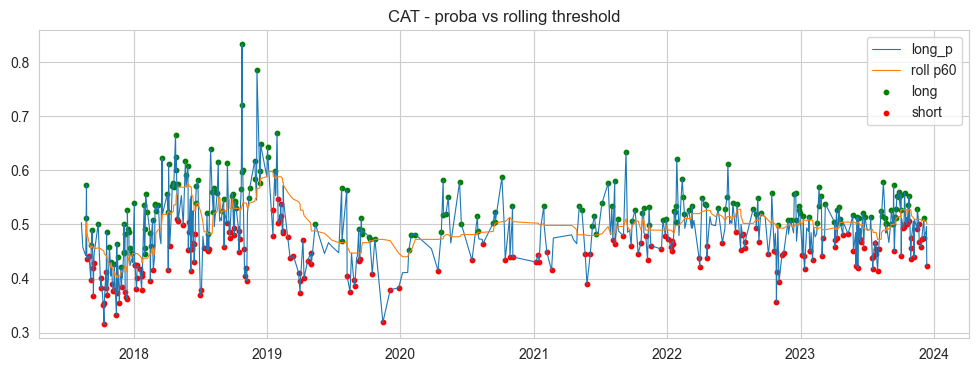

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(ph, x='signal', ax=ax[0])
ax[0].set_title('Post-hoc signal distribution')

cm = confusion_matrix(ph_act['y_dir'], ph_act['signal'], labels=[-1, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred -1', 'pred +1'], yticklabels=['true -1', 'true +1'], ax=ax[1])
ax[1].set_title('Directional confusion (signal != 0)')
plt.tight_layout(); plt.show()

tkr = ph['ticker'].iloc[0]
sub = ph[ph['ticker'] == tkr].sort_values('date')
plt.figure(figsize=(12, 4))
plt.plot(sub['date'], sub['long_p'], label='long_p', lw=0.8)
plt.plot(sub['date'], sub['long_thr'], label='roll p60', lw=0.8)
plt.scatter(sub.loc[sub['signal'] == 1, 'date'], sub.loc[sub['signal'] == 1, 'long_p'], c='g', s=10, label='long')
plt.scatter(sub.loc[sub['signal'] == -1, 'date'], sub.loc[sub['signal'] == -1, 'long_p'], c='r', s=10, label='short')
plt.title(f'{tkr} - proba vs rolling threshold'); plt.legend(); plt.show()

In [12]:
summary_rows = []
for name, p in preds_store.items():
    ps = posthoc_signal(p)
    ps['y_dir'] = np.where(ps['y'] == 1, 1, -1)
    act = ps[ps['signal'] != 0]
    summary_rows.append({
        'model': name,
        'roc_auc': roc_auc_score(ps['y'], ps['proba']),
        'f1_raw': f1_score(ps['y'], (ps['proba'] >= 0.5).astype(int)),
        'recall_raw': recall_score(ps['y'], (ps['proba'] >= 0.5).astype(int)),
        'coverage': len(act) / max(len(ps), 1),
        'dir_acc_posthoc': act['correct'].mean() if 'correct' in act else
                           (act['signal'] == act['y_dir']).mean(),
    })
pd.DataFrame(summary_rows).round(3)

,model,roc_auc,f1_raw,recall_raw,coverage,dir_acc_posthoc
0,xgb,0.501,0.552,0.564,0.766,0.498
1,logreg,0.507,0.523,0.503,0.772,0.500
2,rf,0.501,0.557,0.571,0.768,0.496


## Train final XGBoost on full data, save & smoke-test reload

In [13]:
import os, joblib

MODEL_DIR = '../models/xgb_tb'
os.makedirs(MODEL_DIR, exist_ok=True)

scaler_final = StandardScaler()
X_full = scaler_final.fit_transform(df[feat_cols].values)
y_full = df['label'].values

xgb_final = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.03,
                          subsample=0.8, colsample_bytree=0.8,
                          reg_lambda=1.0, min_child_weight=5,
                          scale_pos_weight=spw,
                          eval_metric='logloss', n_jobs=-1, random_state=0)
xgb_final.fit(X_full, y_full)

# use the median threshold from CV folds for the saved model
final_thr = float(res_df[res_df['model'] == 'xgb']['thr'].median())
print('final XGB threshold:', round(final_thr, 3))

joblib.dump(xgb_final, f'{MODEL_DIR}/xgb_tb.pkl')
joblib.dump(scaler_final, f'{MODEL_DIR}/scaler.pkl')
joblib.dump(feat_cols, f'{MODEL_DIR}/feat_cols.pkl')
joblib.dump(final_thr, f'{MODEL_DIR}/threshold.pkl')
# Persist the embedding StandardScaler+PCA pipeline so inference reuses the exact
# fitted projection instead of refitting PCA on every run.
joblib.dump(emb_pipeline, f'{MODEL_DIR}/emb_pipeline.pkl')
print('saved to', MODEL_DIR)

final XGB threshold: 0.48
saved to ../models/xgb_tb


In [14]:
xgb_loaded = joblib.load(f'{MODEL_DIR}/xgb_tb.pkl')
scaler_loaded = joblib.load(f'{MODEL_DIR}/scaler.pkl')
feat_cols_loaded = joblib.load(f'{MODEL_DIR}/feat_cols.pkl')
emb_pipeline_loaded = joblib.load(f'{MODEL_DIR}/emb_pipeline.pkl')

sample = df[feat_cols_loaded].tail(5).values
X_sample = scaler_loaded.transform(sample)
proba_loaded = xgb_loaded.predict_proba(X_sample)[:, 1]
proba_orig = xgb_final.predict_proba(X_sample)[:, 1]

# Confirm the reloaded emb pipeline matches the in-memory one on a small batch.
emb_sample = emb_mat[:5]
assert np.allclose(emb_pipeline_loaded.transform(emb_sample),
                   emb_pipeline.transform(emb_sample)), 'emb pipeline mismatch!'

print('loaded proba :', proba_loaded.round(4))
print('orig proba   :', proba_orig.round(4))
assert np.allclose(proba_loaded, proba_orig), 'reloaded model mismatch!'
print('smoke test passed')

loaded proba : [0.4939 0.6347 0.547  0.561  0.5321]
orig proba   : [0.4939 0.6347 0.547  0.561  0.5321]
smoke test passed


## Inference on full dataset, export per-article predictions

In [15]:
news_pd = news.to_pandas()
feat_df = df[['ticker', 'date'] + feat_cols].drop_duplicates(['ticker', 'date'])

infer_df = news_pd.merge(feat_df, on=['ticker', 'date'], how='inner')
X_infer = scaler_loaded.transform(infer_df[feat_cols_loaded].values)
infer_df['proba_up'] = xgb_loaded.predict_proba(X_infer)[:, 1]
infer_df['pred'] = (infer_df['proba_up'] >= final_thr).astype(int)

out = infer_df[['id', 'ticker', 'date', 'proba_up', 'pred']]
out_path = f'{DATA_DIR}/predictions/xgb_tb_predictions.parquet'
out.to_parquet(out_path, index=False)
print('exported', out.shape, '->', out_path)
out.head()

exported (90801, 5) -> ../data/predictions/xgb_tb_predictions.parquet


,id,ticker,date,proba_up,pred
0,0,GS,2019-12-09,0.510510,1
1,3,T,2023-02-21,0.490295,1
2,4,UBER,2023-08-23,0.547266,1
3,5,WMT,2023-11-30,0.546510,1
4,8,MRK,2017-02-16,0.464788,0
